<a href="https://colab.research.google.com/github/EgorHI/mnist-influence-project/blob/main/notebooks/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf /content/mnist-influence-project
%cd /content
!git clone https://github.com/EgorHI/mnist-influence-project.git
%cd /content/mnist-influence-project
!pip install -r requirements.txt


/content
Cloning into 'mnist-influence-project'...
remote: Enumerating objects: 111, done.
remote: Total 111 (delta 0), reused 0 (delta 0), pack-reused 111 (from 1)
Receiving objects: 100% (111/111), 40.59 MiB | 15.64 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Updating files: 100% (23/23), done.
/content/mnist-influence-project


Загрузка MNIST и правильное разбиение

In [2]:

# 1. Imports and seed

import random
import numpy as np
import torch

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

seed = 67

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Seed:", seed)

Device: cuda
Seed: 67


In [3]:

# 2. Load MNIST

transform = transforms.ToTensor()

#train часть датасета
mnist_train_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

#test часть датасета
mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Full train size:", len(mnist_train_full))
print("Test size:", len(mnist_test))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.50MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.06MB/s]

Full train size: 60000
Test size: 10000


In [4]:

# 3. Stratified split of TRAIN into 60% / 30% / 10%

targets = mnist_train_full.targets.numpy()
all_indices = np.arange(len(mnist_train_full))

# Сначала делим на 60% и 40%
idx_60, idx_40 = train_test_split(
    all_indices,
    test_size=0.40,
    stratify=targets,
    random_state=seed
)

# Потом 40% делим на 30% и 10%
targets_40 = targets[idx_40]

idx_30, idx_10 = train_test_split(
    idx_40,
    test_size=0.25,
    stratify=targets_40,
    random_state=seed
)

print("Split sizes:")
print("60% split:", len(idx_60))
print("30% split:", len(idx_30))
print("10% split:", len(idx_10))
print("Check total:", len(idx_60) + len(idx_30) + len(idx_10))

Split sizes:
60% split: 36000
30% split: 18000
10% split: 6000
Check total: 60000


In [5]:

# 4. Create subsets

mnist_train_60 = Subset(mnist_train_full, idx_60)
mnist_train_30 = Subset(mnist_train_full, idx_30)
mnist_train_10 = Subset(mnist_train_full, idx_10)

print("Subset sizes:")
print("mnist_train_60:", len(mnist_train_60))
print("mnist_train_30:", len(mnist_train_30))
print("mnist_train_10:", len(mnist_train_10))
print("mnist_test:", len(mnist_test))

Subset sizes:
mnist_train_60: 36000
mnist_train_30: 18000
mnist_train_10: 6000
mnist_test: 10000


In [6]:

# 5. Dataloaders

batch_size = 128

train30_loader = DataLoader(mnist_train_30, batch_size=batch_size, shuffle=True)
train10_loader = DataLoader(mnist_train_10, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

print("Number of batches:")
print("train30_loader:", len(train30_loader))
print("train10_loader:", len(train10_loader))
print("test_loader:", len(test_loader))

Number of batches:
train30_loader: 141
train10_loader: 47
test_loader: 79


In [7]:

# 6. Check class balance

def get_labels_from_subset(full_dataset, subset_indices):
    return full_dataset.targets[subset_indices].numpy()

def print_class_distribution(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    print(f"\n{name}")
    for cls, cnt in zip(unique, counts):
        print(f"class {cls}: {cnt} ({cnt / total:.4f})")

labels_60 = get_labels_from_subset(mnist_train_full, idx_60)
labels_30 = get_labels_from_subset(mnist_train_full, idx_30)
labels_10 = get_labels_from_subset(mnist_train_full, idx_10)
labels_test = mnist_test.targets.numpy()

print_class_distribution("60% split", labels_60)
print_class_distribution("30% split", labels_30)
print_class_distribution("10% split", labels_10)
print_class_distribution("test split", labels_test)


60% split
class 0: 3554 (0.0987)
class 1: 4045 (0.1124)
class 2: 3575 (0.0993)
class 3: 3679 (0.1022)
class 4: 3505 (0.0974)
class 5: 3252 (0.0903)
class 6: 3551 (0.0986)
class 7: 3759 (0.1044)
class 8: 3511 (0.0975)
class 9: 3569 (0.0991)

30% split
class 0: 1777 (0.0987)
class 1: 2023 (0.1124)
class 2: 1787 (0.0993)
class 3: 1839 (0.1022)
class 4: 1753 (0.0974)
class 5: 1627 (0.0904)
class 6: 1775 (0.0986)
class 7: 1879 (0.1044)
class 8: 1755 (0.0975)
class 9: 1785 (0.0992)

10% split
class 0: 592 (0.0987)
class 1: 674 (0.1123)
class 2: 596 (0.0993)
class 3: 613 (0.1022)
class 4: 584 (0.0973)
class 5: 542 (0.0903)
class 6: 592 (0.0987)
class 7: 627 (0.1045)
class 8: 585 (0.0975)
class 9: 595 (0.0992)

test split
class 0: 980 (0.0980)
class 1: 1135 (0.1135)
class 2: 1032 (0.1032)
class 3: 1010 (0.1010)
class 4: 982 (0.0982)
class 5: 892 (0.0892)
class 6: 958 (0.0958)
class 7: 1028 (0.1028)
class 8: 974 (0.0974)
class 9: 1009 (0.1009)


In [8]:

# 7. Quick sanity check: one batch

images, labels = next(iter(train30_loader))

print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Min pixel:", images.min().item())
print("Max pixel:", images.max().item())

Batch images shape: torch.Size([128, 1, 28, 28])
Batch labels shape: torch.Size([128])
Min pixel: 0.0
Max pixel: 1.0


Подготовка ResNet-18 под MNIST

In [9]:

# 8. Fresh ResNet-18 builder for repeated experiments

import os
import json
from datetime import datetime



import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("plots", exist_ok=True)

def build_mnist_resnet18(device):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    # Замораживаем все параметры
    for param in model.parameters():
        param.requires_grad = False

    # Новый первый слой под 1x28x28
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    # Новый последний слой под 10 классов
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 10)

    # Обучаем только новые слои
    for param in model.conv1.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

In [10]:

# 9. Prepare ResNet-18 for MNIST


from torchvision.models import resnet18, ResNet18_Weights

model = build_mnist_resnet18(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:

# 10. Sanity check: one forward pass

images, labels = next(iter(train30_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([128, 1, 28, 28])
Output shape: torch.Size([128, 10])


In [12]:

# 11. Check trainable parameters

trainable_params = []
frozen_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_params.append(name)
    else:
        frozen_params.append(name)

print("Trainable parameters:")
for name in trainable_params:
    print("  ", name)

print("\nNumber of trainable tensors:", len(trainable_params))
print("Number of frozen tensors   :", len(frozen_params))

Trainable parameters:
   conv1.weight
   fc.weight
   fc.bias

Number of trainable tensors: 3
Number of frozen tensors   : 59


Обучение базовой модели на нормальных данных

In [13]:

# 12. Training setup

os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Функция потерь
criterion = nn.CrossEntropyLoss()

# Гиперпараметры
num_epochs = 5

print("Training setup is ready.")

Training setup is ready.


In [14]:
import os
import subprocess
from getpass import getpass

def run_cmd(cmd, check=True):
    result = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed: {cmd}")
    return result

def git_auto_push(
    repo_dir="/content/mnist-influence-project",
    branch="main",
    github_username="EgorHI",
    github_email="evy2006@mail.ru",
    commit_message="auto: save experiment artifacts"
):
    os.chdir(repo_dir)

    token = getpass("Paste GitHub token: ").strip()

    run_cmd(f'git config user.name "{github_username}"')
    run_cmd(f'git config user.email "{github_email}"')

    clean_remote = f"https://github.com/{github_username}/mnist-influence-project.git"
    auth_remote = clean_remote.replace("https://", f"https://{github_username}:{token}@")

    run_cmd(f'git remote set-url origin "{clean_remote}"')
    run_cmd("git add .", check=False)

    status = run_cmd("git status --porcelain", check=False).stdout.strip()
    if not status:
        print("No changes to commit.")
        return

    run_cmd(f'git commit -m "{commit_message}"')
    run_cmd(f'git remote set-url origin "{auth_remote}"')
    run_cmd(f"git push origin {branch}")
    run_cmd(f'git remote set-url origin "{clean_remote}"')

    print("GitHub push completed.")

In [15]:

# 13. Helper functions

def set_batchnorm_eval(m):
    """
    Если слой - BatchNorm, переводим его в eval(),
    чтобы не обновлять внутреннюю статистику.
    Это полезно, когда backbone фактически заморожен.
    """
    if isinstance(m, nn.BatchNorm2d):
        m.eval()

#Обучает модель одну эпоху
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    # Замораживаем поведение BatchNorm-слоев (обучаем первый и последний слои)
    model.apply(set_batchnorm_eval)

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step() #Обновляем веса

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()

def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    loss_value = running_loss / total
    acc_value = correct / total
    return loss_value, acc_value

def save_metrics_to_json(filepath, metrics_dict):
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(metrics_dict, f, ensure_ascii=False, indent=2)

In [16]:

# 14. Train/evaluate one experiment and save metrics

def run_experiment(
    train_loader,
    train_subset_name,
    train_subset_size,
    experiment_name,
    lr=1e-3,
    num_epochs=5,
    metrics_path=None
):

    model = build_mnist_resnet18(device)

    criterion_local = nn.CrossEntropyLoss()
    # Оптимизатор: обновляем только обучаемые параметры
    optimizer_local = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_test_acc = 0.0

    best_model_path = f"models/{experiment_name}.pt"

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion_local,
            optimizer=optimizer_local,
            device=device
        )

        test_loss, test_acc = evaluate(
            model=model,
            loader=test_loader,
            criterion=criterion_local,
            device=device
        )

        history["train_loss"].append(float(train_loss))
        history["train_acc"].append(float(train_acc))
        history["test_loss"].append(float(test_loss))
        history["test_acc"].append(float(test_acc))

        print(
            f"[{experiment_name}] "
            f"Epoch {epoch}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}"
        )
         # Сохраняем лучшую модель по test accuracy
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=device))

    final_test_loss, final_test_acc = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion_local,
        device=device
    )

    metrics = {
        "experiment_name": experiment_name,
        "timestamp": datetime.now().isoformat(),
        "random_seed": seed,
        "train_subset_name": train_subset_name,
        "train_subset_size": int(train_subset_size),
        "test_subset_name": "mnist_test",
        "test_subset_size": int(len(mnist_test)),
        "num_epochs": int(num_epochs),
        "learning_rate": float(lr),
        "final_test_loss": float(final_test_loss),
        "final_test_accuracy": float(final_test_acc),
        "best_test_accuracy_during_training": float(best_test_acc),
        "model_path": best_model_path
    }

    if metrics_path is None:
        metrics_path = f"logs/{experiment_name}_metrics.json"

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)
    print("\nTraining finished.")
    print("Best test accuracy:", round(best_test_acc, 4))
    print("Best model saved to:", best_model_path)
    print("Final test loss:", round(final_test_loss, 4))
    print("Final test accuracy:", round(final_test_acc, 4))
    print("Metrics saved to:", metrics_path)

    return model, metrics, history

In [17]:

# 15. Train baseline model on normal data

model, baseline_metrics, history = run_experiment(
    train_loader=train30_loader,
    train_subset_name="mnist_train_30",
    train_subset_size=len(mnist_train_30),
    experiment_name="baseline_normal_data",
    lr=1e-3,
    num_epochs=num_epochs,
    metrics_path="logs/baseline_metrics.json"
)

best_model_path = baseline_metrics["model_path"]
best_test_acc = baseline_metrics["best_test_accuracy_during_training"]
final_test_loss = baseline_metrics["final_test_loss"]
final_test_acc = baseline_metrics["final_test_accuracy"]

print(json.dumps(baseline_metrics, ensure_ascii=False, indent=2))

[baseline_normal_data] Epoch 1/5 | train_loss=1.2353 | train_acc=0.6505 | test_loss=0.5196 | test_acc=0.8578
[baseline_normal_data] Epoch 2/5 | train_loss=0.4240 | train_acc=0.8829 | test_loss=0.3148 | test_acc=0.9127
[baseline_normal_data] Epoch 3/5 | train_loss=0.3018 | train_acc=0.9142 | test_loss=0.2576 | test_acc=0.9271
[baseline_normal_data] Epoch 4/5 | train_loss=0.2484 | train_acc=0.9297 | test_loss=0.2167 | test_acc=0.9360
[baseline_normal_data] Epoch 5/5 | train_loss=0.2154 | train_acc=0.9381 | test_loss=0.1960 | test_acc=0.9424

Training finished.
Best test accuracy: 0.9424
Best model saved to: models/baseline_normal_data.pt
Final test loss: 0.196
Final test accuracy: 0.9424
Metrics saved to: logs/baseline_metrics.json
{
  "experiment_name": "baseline_normal_data",
  "timestamp": "2026-03-23T08:37:31.539756",
  "random_seed": 67,
  "train_subset_name": "mnist_train_30",
  "train_subset_size": 18000,
  "test_subset_name": "mnist_test",
  "test_subset_size": 10000,
  "num_epoc

Реализация influence score

In [18]:

# 16. Influence setup

from tqdm.auto import tqdm #показать полоску с числами


model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# Loader для proxy-части (это 10% split из train)
proxy10_loader = DataLoader(
    mnist_train_10,
    batch_size=128,
    shuffle=False
)

# Loader для LiSSA / HVP по train30
influence_train_loader = DataLoader(
    mnist_train_30,
    batch_size=128,
    shuffle=True
)

# Loader по одному объекту, чтобы считать influence score для каждого train-примера
train30_single_loader = DataLoader(
    mnist_train_30,
    batch_size=1,
    shuffle=False
)

print("Influence loaders are ready.")
print("proxy10 size:", len(mnist_train_10))
print("train30 size:", len(mnist_train_30))

Influence loaders are ready.
proxy10 size: 6000
train30 size: 18000


In [19]:

# 17. Influence helper functions

def get_trainable_params(model):
    return [p for p in model.parameters() if p.requires_grad]


def flatten_tensors(tensors):

    return torch.cat([t.contiguous().view(-1) for t in tensors])

# H- матрица 2 производных
def hvp(loss, params, vec):

    #Hessian-vector product: H * vec
    #где H — Hessian loss по trainable params


    first_grads = torch.autograd.grad(
        loss,
        params,
        create_graph=True,
        retain_graph=True
    )
    flat_first_grads = flatten_tensors(first_grads)

    grad_dot_vec = torch.dot(flat_first_grads, vec)

    hv = torch.autograd.grad(
        grad_dot_vec,
        params,
        retain_graph=False
    )

    hv = [h.detach() for h in hv]
    return flatten_tensors(hv)


@torch.no_grad()

def count_num_trainable_params(model):
    total = 0
    for p in model.parameters():
        if p.requires_grad:
            total += p.numel()
    return total


def compute_dataset_gradient(model, loader, criterion, device, max_batches=None):

    #Считает средний градиент loss по всему loader.
    #Это будет v = grad_theta L_proxy(theta).

    model.eval()
    params = get_trainable_params(model)

    grad_accumulator = None
    total_items = 0

    for batch_idx, (images, labels) in enumerate(loader):

        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        model.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)


        grads = torch.autograd.grad(loss, params, retain_graph=False, create_graph=False)

        flat_grads = flatten_tensors([g.detach() for g in grads])

        batch_size = images.size(0)

        if grad_accumulator is None:
            grad_accumulator = flat_grads * batch_size
        else:
            grad_accumulator += flat_grads * batch_size

        total_items += batch_size

    avg_grad = grad_accumulator / total_items
    return avg_grad

#Эта функция выдаёт вектор, который нужен для influence score.
#LiSSA — это способ дёшево приблизить H^(-1)v, не строя и не обращая Hessian напрямую.
def lissa_inverse_hvp(
    model,
    train_loader,
    criterion,
    device,
    v,
    damping=0.01,
    scale=25.0,
    recursion_depth=200,
    num_repeats=1
):

    #LiSSA-аппроксимация для H^{-1} v.

    model.eval()
    params = get_trainable_params(model)

    ihvp = torch.zeros_like(v)

    for repeat in range(num_repeats):
        cur_estimate = v.clone()

        data_iter = iter(train_loader)

        for _ in tqdm(range(recursion_depth), desc=f"LiSSA repeat {repeat+1}/{num_repeats}"):
            try:
                images, labels = next(data_iter)
            except StopIteration:
                data_iter = iter(train_loader)
                images, labels = next(data_iter)

            images = images.to(device)
            labels = labels.to(device)

            model.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            hv = hvp(loss, params, cur_estimate)

            cur_estimate = v + (1.0 - damping) * cur_estimate - hv / scale

        ihvp += cur_estimate / scale

    ihvp /= num_repeats
    return ihvp

def compute_single_example_grad(model, image, label, criterion, device):

    #Градиент loss по одному train-примеру.

    model.eval()
    params = get_trainable_params(model)

    image = image.to(device)
    label = label.to(device)

    model.zero_grad(set_to_none=True)
    outputs = model(image)
    loss = criterion(outputs, label)

    grads = torch.autograd.grad(loss, params, retain_graph=False, create_graph=False)
    flat_grads = flatten_tensors([g.detach() for g in grads])

    return flat_grads


print("Trainable parameter count:", count_num_trainable_params(model))

Trainable parameter count: 8266


In [20]:

# 18. Compute proxy gradient on 10% split

v_proxy = compute_dataset_gradient(
    model=model,
    loader=proxy10_loader,
    criterion=criterion,
    device=device,
    max_batches=None
)

print("Proxy gradient shape:", v_proxy.shape)
print("Proxy gradient norm :", torch.norm(v_proxy).item())

Proxy gradient shape: torch.Size([8266])
Proxy gradient norm : 0.30740416049957275


In [21]:

# 19. Compute inverse-HVP approximation

# Стартовые гиперпараметры.

s_test = lissa_inverse_hvp(
    model=model,
    train_loader=influence_train_loader,
    criterion=criterion,
    device=device,
    v=v_proxy,
    damping=0.01,
    scale=25.0,
    recursion_depth=500,
    num_repeats=3
)

print("s_test shape:", s_test.shape)
print("s_test norm :", torch.norm(s_test).item())

LiSSA repeat 1/3:   0%|          | 0/500 [00:00<?, ?it/s]

LiSSA repeat 2/3:   0%|          | 0/500 [00:00<?, ?it/s]

LiSSA repeat 3/3:   0%|          | 0/500 [00:00<?, ?it/s]

s_test shape: torch.Size([8266])
s_test norm : 0.22157293558120728


In [22]:

# 20. Compute influence scores for all samples in train30

influence_scores = []

n_train30 = len(mnist_train_30)

for local_idx, (image, label) in enumerate(tqdm(train30_single_loader, desc="Influence scores")):

    grad_z = compute_single_example_grad(
        model=model,
        image=image,
        label=label,
        criterion=criterion,
        device=device
    )

    score = -torch.dot(grad_z, s_test).item() / n_train30

    influence_scores.append(score)

influence_scores = np.array(influence_scores, dtype=np.float64)

print("Done.")
print("Num scores:", len(influence_scores))
print("Min score :", influence_scores.min())
print("Max score :", influence_scores.max())
print("Mean      :", influence_scores.mean())

Influence scores:   0%|          | 0/18000 [00:00<?, ?it/s]

Done.
Num scores: 18000
Min score : -5.465312798817952e-05
Max score : 6.493237945768569e-05
Mean      : -5.673139705480397e-07


In [23]:
def select_influential_indices(scores, fraction):
    k = max(1, int(len(scores) * fraction))

    order = np.argsort(scores)   # сортировка по самому значению, не по модулю

    least = order[:k]            # самые маленькие influence score
    most = order[-k:]            # самые большие influence score

    return k, most, least

Выбор top 5% и bottom 5% по influence

In [24]:

# 21. Select top 5% most and least influential samples

top_fraction = 1/6

top_k, most_influential_local, least_influential_local = select_influential_indices(
    influence_scores,
    top_fraction
)

# Индексы внутри исходного train MNIST (а не только внутри Subset)
# Переводит индексы из локальных в исходные индексы полного MNIST train.
most_influential_original = [int(idx_30[i]) for i in most_influential_local]
least_influential_original = [int(idx_30[i]) for i in least_influential_local]

print("k =", top_k)
print("Most influential local indices  (first 10):", most_influential_local[:10])
print("Least influential local indices (first 10):", least_influential_local[:10])

print("Most influential original indices  (first 10):", most_influential_original[:10])
print("Least influential original indices (first 10):", least_influential_original[:10])

k = 3000
Most influential local indices  (first 10): [10497  8662  6696 13055  9316  7274    11  3824   177 15268]
Least influential local indices (first 10): [ 3701   616 14289   798  7533 13419 15611  1760  3894 17009]
Most influential original indices  (first 10): [4496, 19283, 52871, 44515, 20404, 48835, 46186, 39946, 48923, 2704]
Least influential original indices (first 10): [19877, 57342, 39342, 8765, 19007, 56513, 48820, 54262, 34976, 15979]


In [25]:

# 22. Save influence results to JSON

os.makedirs("logs/influence", exist_ok=True)

influence_results = {
    "timestamp": datetime.now().isoformat(),
    "random_seed": seed,
    "source_subset_name": "mnist_train_30",
    "source_subset_size": len(mnist_train_30),
    "proxy_subset_name": "mnist_train_10",
    "proxy_subset_size": len(mnist_train_10),
    "selection_rule": "absolute_influence_score",
    "top_fraction": top_fraction,
    "num_selected": top_k,

    "most_influential_local_indices": [int(i) for i in most_influential_local],
    "least_influential_local_indices": [int(i) for i in least_influential_local],

    "most_influential_original_mnist_train_indices": most_influential_original,
    "least_influential_original_mnist_train_indices": least_influential_original,

    "most_influential_scores": [float(influence_scores[i]) for i in most_influential_local],
    "least_influential_scores": [float(influence_scores[i]) for i in least_influential_local]
}

influence_json_path = "logs/influence_top_bottom_5_percent.json"

with open(influence_json_path, "w", encoding="utf-8") as f:
    json.dump(influence_results, f, ensure_ascii=False, indent=2)

print("Influence indices saved to:", influence_json_path)

Influence indices saved to: logs/influence_top_bottom_5_percent.json


Блок атаки label flipping

In [26]:

# 23. Label flipping attack helpers


from torch.utils.data import Dataset

def sample_wrong_label(true_label, rng, num_classes=10):
    """
    Равномерно выбирает случайный класс, отличный от true_label.
    """
    new_label = rng.integers(0, num_classes - 1)
    if new_label >= true_label:
        new_label += 1
    return int(new_label)

class PoisonedSubset(Dataset):
    """
    Датасет поверх mnist_train_30:
    - берем только selected_local_indices
    - для части индексов подменяем label через poisoned_label_map
    """

    def __init__(self, base_subset, selected_local_indices, poisoned_label_map):
        self.base_subset = base_subset
        self.selected_local_indices = [int(i) for i in selected_local_indices]
        self.poisoned_label_map = {int(k): int(v) for k, v in poisoned_label_map.items()}

    def __len__(self):
        return len(self.selected_local_indices)

    def __getitem__(self, idx):
        local_idx = self.selected_local_indices[idx]
        image, original_label = self.base_subset[local_idx]

        if local_idx in self.poisoned_label_map:
            label = self.poisoned_label_map[local_idx]
        else:
            label = int(original_label)

        return image, label


def build_poisoned_dataset_full(
    base_subset,
    poisoned_local_indices,
    seed=42,
    num_classes=10
):
    rng = np.random.default_rng(seed)
    n = len(base_subset)


    poisoned_local_indices = sorted(set(int(i) for i in poisoned_local_indices))
    poisoned_label_map = {}


    for local_idx in poisoned_local_indices:
        _, true_label = base_subset[local_idx]
        true_label = int(true_label)
        poisoned_label_map[local_idx] = sample_wrong_label(
            true_label, rng, num_classes=num_classes
        )

    final_local_indices = np.arange(n, dtype=np.int64)

    poisoned_dataset = PoisonedSubset(
        base_subset=base_subset,
        selected_local_indices=final_local_indices.tolist(),
        poisoned_label_map=poisoned_label_map
    )

    return poisoned_dataset, final_local_indices, poisoned_label_map

In [27]:

# 24. Build poisoned datasets

poison_fraction_inside_train30 = 5 / 30

#poison_k, most_poison_local, least_poison_local = select_influential_indices(
    #influence_scores,
    #poison_fraction_inside_train30
#)

poisoned_most_dataset, poisoned_most_final_indices, poisoned_most_label_map = build_poisoned_dataset_full(
    base_subset=mnist_train_30,
    poisoned_local_indices=most_influential_local,
    seed=seed + 100,
    num_classes=10
)

poisoned_least_dataset, poisoned_least_final_indices, poisoned_least_label_map = build_poisoned_dataset_full(
    base_subset=mnist_train_30,
    poisoned_local_indices=least_influential_local,
    seed=seed + 200,
    num_classes=10
)

print("Poisoned MOST dataset size :", len(poisoned_most_dataset))
print("Poisoned LEAST dataset size:", len(poisoned_least_dataset))

print("Num poisoned MOST examples :", len(poisoned_most_label_map))
print("Num poisoned LEAST examples:", len(poisoned_least_label_map))

Poisoned MOST dataset size : 18000
Poisoned LEAST dataset size: 18000
Num poisoned MOST examples : 3000
Num poisoned LEAST examples: 3000


In [28]:

# 25. Dataloaders for poisoned training

batch_size = 128

poisoned_most_loader = DataLoader(
    poisoned_most_dataset,
    batch_size=batch_size,
    shuffle=True
)

poisoned_least_loader = DataLoader(
    poisoned_least_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("poisoned_most_loader batches :", len(poisoned_most_loader))
print("poisoned_least_loader batches:", len(poisoned_least_loader))

poisoned_most_loader batches : 141
poisoned_least_loader batches: 141


In [29]:

# 26. Sanity check: inspect some flipped labels

def inspect_flips(base_subset, poisoned_label_map, num_examples=10):

    poisoned_items = list(poisoned_label_map.items())[:num_examples]

    for local_idx, new_label in poisoned_items:
        _, old_label = base_subset[local_idx]
        print(f"local_idx={local_idx} | old_label={int(old_label)} -> new_label={new_label}")

print("MOST influential flips:")
inspect_flips(mnist_train_30, poisoned_most_label_map, num_examples=10)

print("\nLEAST influential flips:")
inspect_flips(mnist_train_30, poisoned_least_label_map, num_examples=10)

MOST influential flips:
local_idx=2 | old_label=4 -> new_label=7
local_idx=5 | old_label=4 -> new_label=1
local_idx=11 | old_label=6 -> new_label=9
local_idx=13 | old_label=0 -> new_label=6
local_idx=33 | old_label=4 -> new_label=8
local_idx=38 | old_label=4 -> new_label=6
local_idx=40 | old_label=7 -> new_label=8
local_idx=45 | old_label=6 -> new_label=1
local_idx=60 | old_label=8 -> new_label=3
local_idx=66 | old_label=4 -> new_label=8

LEAST influential flips:
local_idx=1 | old_label=8 -> new_label=5
local_idx=9 | old_label=9 -> new_label=5
local_idx=12 | old_label=2 -> new_label=9
local_idx=19 | old_label=5 -> new_label=3
local_idx=20 | old_label=2 -> new_label=3
local_idx=27 | old_label=8 -> new_label=7
local_idx=29 | old_label=9 -> new_label=0
local_idx=43 | old_label=9 -> new_label=0
local_idx=50 | old_label=8 -> new_label=4
local_idx=52 | old_label=0 -> new_label=5


In [30]:

# 27. Save attack configuration to JSON

os.makedirs("logs/attacks", exist_ok=True)

attack_info = {
    "timestamp": datetime.now().isoformat(),
    "random_seed": seed,
    "source_subset_name": "mnist_train_30",
    "source_subset_size": len(mnist_train_30),
    "poison_fraction_inside_train30": poison_fraction_inside_train30,

    "most_attack": {
        "num_poisoned": len(poisoned_most_label_map),
        "final_dataset_size": len(poisoned_most_dataset),
        "poisoned_local_indices": [int(i) for i in sorted(poisoned_most_label_map.keys())]
    },

    "least_attack": {
        "num_poisoned": len(poisoned_least_label_map),
        "final_dataset_size": len(poisoned_least_dataset),
        "poisoned_local_indices": [int(i) for i in sorted(poisoned_least_label_map.keys())]
    }
}

attack_json_path = "logs/label_flipping_attack_info.json"

with open(attack_json_path, "w", encoding="utf-8") as f:
    json.dump(attack_info, f, ensure_ascii=False, indent=2)

print("Attack config saved to:", attack_json_path)

Attack config saved to: logs/label_flipping_attack_info.json


Повторное обучение на двух poisoned-наборах и график

In [31]:

# 28. Retrain on two poisoned datasets

poison_num_epochs = 5
poison_lr = 1e-3

least_model, least_metrics, least_history = run_experiment(
    train_loader=poisoned_least_loader,
    train_subset_name="poisoned_least_dataset",
    train_subset_size=len(poisoned_least_dataset),
    experiment_name="resnet18_mnist_poisoned_least",
    lr=poison_lr,
    num_epochs=poison_num_epochs
)

most_model, most_metrics, most_history = run_experiment(
    train_loader=poisoned_most_loader,
    train_subset_name="poisoned_most_dataset",
    train_subset_size=len(poisoned_most_dataset),
    experiment_name="resnet18_mnist_poisoned_most",
    lr=poison_lr,
    num_epochs=poison_num_epochs
)

print("\nFinished poisoned retraining.")
print("Least influential poison final test acc:", round(least_metrics["final_test_accuracy"], 4))
print("Most  influential poison final test acc:", round(most_metrics["final_test_accuracy"], 4))

[resnet18_mnist_poisoned_least] Epoch 1/5 | train_loss=1.5210 | train_acc=0.5608 | test_loss=0.7308 | test_acc=0.8418
[resnet18_mnist_poisoned_least] Epoch 2/5 | train_loss=0.9402 | train_acc=0.7636 | test_loss=0.5093 | test_acc=0.8939
[resnet18_mnist_poisoned_least] Epoch 3/5 | train_loss=0.8541 | train_acc=0.7881 | test_loss=0.4545 | test_acc=0.9008
[resnet18_mnist_poisoned_least] Epoch 4/5 | train_loss=0.8124 | train_acc=0.7972 | test_loss=0.4353 | test_acc=0.9062
[resnet18_mnist_poisoned_least] Epoch 5/5 | train_loss=0.7899 | train_acc=0.8009 | test_loss=0.4157 | test_acc=0.9156

Training finished.
Best test accuracy: 0.9156
Best model saved to: models/resnet18_mnist_poisoned_least.pt
Final test loss: 0.4157
Final test accuracy: 0.9156
Metrics saved to: logs/resnet18_mnist_poisoned_least_metrics.json
[resnet18_mnist_poisoned_most] Epoch 1/5 | train_loss=1.5787 | train_acc=0.5471 | test_loss=0.7696 | test_acc=0.8230
[resnet18_mnist_poisoned_most] Epoch 2/5 | train_loss=1.0035 | trai

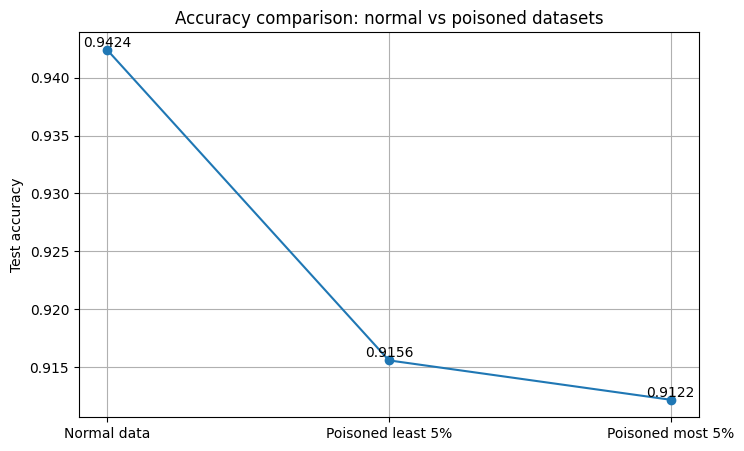

Plot saved to: plots/final_accuracy_3_points.png


In [32]:

# 29. Final 3-point accuracy graph

import matplotlib.pyplot as plt

baseline_acc = float(final_test_acc)
least_acc = float(least_metrics["final_test_accuracy"])
most_acc = float(most_metrics["final_test_accuracy"])

labels = [
    "Normal data",
    "Poisoned least 5%",
    "Poisoned most 5%"
]
values = [baseline_acc, least_acc, most_acc]

plt.figure(figsize=(8, 5))
plt.plot(labels, values, marker="o")
plt.ylabel("Test accuracy")
plt.title("Accuracy comparison: normal vs poisoned datasets")
plt.grid(True)

for x, y in zip(labels, values):

    plt.text(x, y, f"{y:.4f}", ha="center", va="bottom")

plot_path = "plots/final_accuracy_3_points.png"
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Plot saved to:", plot_path)

In [33]:

# 30. Save final comparison to JSON

comparison = {
    "timestamp": datetime.now().isoformat(),
    "random_seed": seed,
    "normal_data_accuracy": float(baseline_acc),
    "poisoned_least_5_percent_accuracy": float(least_acc),
    "poisoned_most_5_percent_accuracy": float(most_acc)
}

comparison_path = "logs/final_accuracy_comparison.json"
with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)

print("Final comparison saved to:", comparison_path)
print(json.dumps(comparison, ensure_ascii=False, indent=2))

Final comparison saved to: logs/final_accuracy_comparison.json
{
  "timestamp": "2026-03-23T08:43:39.607407",
  "random_seed": 67,
  "normal_data_accuracy": 0.9424,
  "poisoned_least_5_percent_accuracy": 0.9156,
  "poisoned_most_5_percent_accuracy": 0.9122
}


In [34]:
# 31. Push all artifacts to GitHub

git_auto_push(
    repo_dir="/content/mnist-influence-project",
    branch="main",
    github_username="EgorHI",
    github_email="eyv2006@mail.ru",
    commit_message="auto: save metrics, models, plots and notebook"
)

Paste GitHub token: ··········
M  logs/baseline_metrics.json
M  logs/final_accuracy_comparison.json
M  logs/influence_top_bottom_5_percent.json
M  logs/label_flipping_attack_info.json
M  logs/resnet18_mnist_poisoned_least_metrics.json
M  logs/resnet18_mnist_poisoned_most_metrics.json
M  models/baseline_normal_data.pt
M  models/resnet18_mnist_poisoned_least.pt
M  models/resnet18_mnist_poisoned_most.pt
M  plots/final_accuracy_3_points.png

[main c168a6f] auto: save metrics, models, plots and notebook
 10 files changed, 21994 insertions(+), 21994 deletions(-)
 rewrite logs/influence_top_bottom_5_percent.json (72%)
 rewrite plots/final_accuracy_3_points.png (99%)

To https://github.com/EgorHI/mnist-influence-project.git
   ac10e51..c168a6f  main -> main

GitHub push completed.


In [35]:
import json

path = "notebooks/assignment.ipynb"

with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

if "metadata" in nb and "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("widgets metadata removed")

widgets metadata removed


In [36]:
!git rm assignment.ipynb
!git commit -m "Remove duplicate root notebook"
!git push

rm 'assignment.ipynb'
[main c70b44f] Remove duplicate root notebook
 1 file changed, 3709 deletions(-)
 delete mode 100644 assignment.ipynb
fatal: could not read Username for 'https://github.com': No such device or address
